# Week 3–4 Lab

## Exploring GloVe Embeddings and Building a Bigram Language Model

**Live-delivery notebook · Conda environment: `GenAI2505`**

This notebook is both an executable demonstration and a lecturer script. The visual labels mean:

- **RUN** — execute this cell during the core session.
- **DISCUSS** — explain the idea; no code needs to run.
- **OPTIONAL DEMO** — useful, but safe to skip.
- **OPTIONAL EXTENSION** — additional material beyond the core lab.

### Opening

By the end of the session, students should be able to explain what an embedding represents, compare embeddings, construct a smoothed bigram language model, classify short documents using log-likelihood, and interpret perplexity.

## What we will build today

The lab contains **two independent NLP stories**. They both represent language numerically, but they answer different questions.

### Story A — meaning as geometry

`co-occurrence → PMI → GloVe → cosine similarity → analogy → document vectors`

We begin with the distributional idea that words used in similar contexts tend to have related meanings. We first see that idea in counts, then use pretrained GloVe vectors to explore semantic geometry.

### Story B — language as a sequence

`tokens → bigram counts → probabilities → smoothing → log-likelihood → perplexity`

Here, the question is not “which words have similar meanings?” It is “given one word, how probable is the next word?” We will construct two tiny statistical language models from scratch.

### Setup

**RUN**

- “This first cell only imports the tools used throughout the lab. NumPy handles vectors, PCA gives us a two-dimensional view, and Matplotlib draws the plot.”
- “`Counter` and `defaultdict` are standard Python structures that will make the bigram counts easy to inspect.”
- “There is no special NLP library doing the language-model work for us. Part B will be explicit Python so we can see every count and probability.”

### Expected output

A short confirmation line. If the imports fail, confirm that the notebook kernel is **Python (`GenAI2505`)**.

In [1]:
import math
import time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Imports ready — using the GenAI2505 kernel.")

Imports ready — using the GenAI2505 kernel.


# Part A — Exploring GloVe Embeddings

## A0 — Co-occurrence and PMI

### What are we trying to do?

Before using pretrained vectors, we will see the raw idea behind distributional semantics: count which **target words** occur near which **context words**.

In the table below:

- rows are target words (`cat`, `dog`, `car`);
- columns are context words (`eats`, `meows`, `barks`, `purrs`, `runs`);
- a cell is a co-occurrence count, such as `table["cat"]["meows"] == 12`;
- `row_sum[w]` is the total for target word `w`;
- `col_sum[c]` is the total for context word `c`;
- `N` is the total of every cell.

PMI asks a focused question:

> Does this pair occur together **more frequently than chance would suggest**?

$$\operatorname{PMI}(w,c)=\log\left(\frac{C(w,c)\,N}{C(w)\,C(c)}\right)$$

The code mapping is direct:

| Formula | Python |
|---|---|
| $C(w,c)$ | `table[w][c]` or `cnt` |
| $C(w)$ | `row_sum[w]` |
| $C(c)$ | `col_sum[c]` |
| $N$ | `N` |

### Co-occurrence and PMI

**RUN**

- “A raw count tells us how often two items met. PMI adjusts that count for how common the word and context are overall.”
- “`cat + meows` occurs 12 times. `cat + eats` occurs only 5 times, and `eats` is also shared with dogs. Which pair do you expect to be more distinctive?”
- “Look at the formula as observed association divided by what the marginals make us expect. A positive PMI means ‘more than chance’; a negative PMI means ‘less than chance.’”
- “For a zero cell such as `dog + meows`, the logarithm would receive zero. Mathematically that produces negative infinity, so the function handles it explicitly.”

### Ask the class

Which should have higher PMI: `cat + meows` or `cat + eats`? What should happen for `dog + meows`?

### What to notice

`cat + meows` should be more strongly associated. `dog + meows` prints `-inf`. **PPMI** is a common variant that clips negative PMI values to zero: $\max(\mathrm{PMI}, 0)$. We mention it here, but do not need another coding exercise.

In [2]:
table = {
    "cat": {"eats": 5, "meows": 12, "barks": 1, "purrs": 10, "runs": 8},
    "dog": {"eats": 6, "meows": 0, "barks": 15, "purrs": 0, "runs": 9},
    "car": {"eats": 0, "meows": 0, "barks": 0, "purrs": 0, "runs": 7},
}

words = list(table)
ctxs = ["eats", "meows", "barks", "purrs", "runs"]
row_sum = {w: sum(table[w].values()) for w in words}
col_sum = {c: sum(table[w][c] for w in words) for c in ctxs}
N = sum(row_sum.values())

print("row_sum:", row_sum)
print("col_sum:", col_sum)
print("N:", N)


def pmi(w, c):
    count = table[w][c]
    if count == 0:
        return float("-inf")
    return math.log((count * N) / (row_sum[w] * col_sum[c]))


for w, c in [("cat", "meows"), ("cat", "eats"), ("dog", "meows")]:
    print(f"PMI({w}, {c}) = {pmi(w, c):.4f}")

row_sum: {'cat': 36, 'dog': 30, 'car': 7}
col_sum: {'eats': 11, 'meows': 12, 'barks': 16, 'purrs': 10, 'runs': 24}
N: 73
PMI(cat, meows) = 0.7069
PMI(cat, eats) = -0.0815
PMI(dog, meows) = -inf


### Key idea

PMI is not simply “large count = important.” It measures how **surprising and distinctive** a pairing is after accounting for the frequencies of both items.

## A1 — Loading pretrained GloVe

GloVe is **pretrained**: someone has already learned the vectors from a very large text collection. The file `glove.6B.100d.txt` contains approximately **400,000 words**, each followed by **100 floating-point numbers**.

One individual dimension is not usually human-interpretable. Meaning emerges from relationships among whole vectors: their directions, distances, and recurring offsets.

Place `glove.6B.100d.txt` in the same directory as this notebook. The file is about 330 MB and is deliberately **not downloaded automatically**.

### Load GloVe

**RUN**

- “The loader reads one line at a time. The first item is the word; the remaining 100 items become a NumPy vector.”
- “We store the result in a dictionary, so `glove['cat']` retrieves the vector for the word `cat`.”
- “The file check is intentional. If the file is missing, the message tells us exactly what must be placed beside the notebook.”
- “Loading can take a short moment because we are reading roughly 400,000 rows.”

### Expected output

Approximately `Loaded 400000 word vectors, each of dimension 100`.

In [3]:
def load_glove(filepath):
    vectors = {}
    with open(filepath, "r", encoding="utf-8") as file:
        for line in file:
            parts = line.split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            vectors[word] = vector
    return vectors


glove_path = Path("glove.6B.100d.txt")
if not glove_path.is_file():
    raise FileNotFoundError(
        "GloVe file missing: place 'glove.6B.100d.txt' in the same directory "
        "as this notebook, then restart the kernel and run all cells. "
        "The notebook will not download the 330 MB file automatically."
    )

glove = load_glove(glove_path)
print(
    f"Loaded {len(glove)} word vectors, "
    f"each of dimension {len(next(iter(glove.values())))}"
)

Loaded 400000 word vectors, each of dimension 100


### Inspect one embedding

**RUN**

- “A word embedding is not an abstract object in the code: it is simply a NumPy array.”
- “The shape confirms that `cat` has 100 dimensions.”
- “We print only the first ten values because all 100 values are too much to inspect individually.”
- “Do not try to name each coordinate. The useful information lives in how this vector relates to other vectors.”

### Expected output

`(100,)`, followed by ten decimal values.

In [4]:
print("glove['cat'].shape:", glove["cat"].shape)
print("glove['cat'][:10]:", glove["cat"][:10])

glove['cat'].shape: (100,)
glove['cat'][:10]: [ 0.23088   0.28283   0.6318   -0.59411  -0.58599   0.63255   0.24402
 -0.14108   0.060815 -0.7898  ]


## A2 — Cosine similarity

### What are we trying to do?

We need a numerical way to say whether two word vectors point in similar directions. Cosine similarity compares **direction**, with the vector lengths divided out:

$$\cos(u,v)=\frac{u\cdot v}{\lVert u\rVert\lVert v\rVert}$$

| Formula part | Python |
|---|---|
| numerator $u\cdot v$ | `np.dot(u, v)` |
| $\lVert u\rVert$ | `np.linalg.norm(u)` |
| $\lVert v\rVert$ | `np.linalg.norm(v)` |
| whole fraction | `cosine_similarity(u, v)` |

Vectors pointing in the same direction have a value near 1; unrelated directions tend nearer 0; opposite directions can be negative.

### Cosine similarity

**RUN**

- “Imagine each word as an arrow from the origin in 100-dimensional space. Cosine similarity asks how closely the arrows point in the same direction.”
- “The dot product is the numerator, but it is **not by itself cosine similarity**. We must divide by both vector norms.”
- “Before we run it: would you expect `cat–dog` or `cat–car` to have the larger cosine similarity?”
- “Finally, a vector compared with itself should point in exactly the same direction, so `cat–cat` should be approximately 1.”

### Common mistake

Calling `np.dot(u, v)` cosine similarity. Without normalization, vector magnitude can dominate the comparison.

### Expected answer

`cat–dog` should be larger than `cat–car`; `cat–cat` should be approximately `1.0` (small floating-point differences are normal).

In [5]:
def cosine_similarity(u, v):
    numerator = np.dot(u, v)
    denominator = np.linalg.norm(u) * np.linalg.norm(v)
    return numerator / denominator


print(f"cat vs dog: {cosine_similarity(glove['cat'], glove['dog']):.4f}")
print(f"cat vs car: {cosine_similarity(glove['cat'], glove['car']):.4f}")
print(f"cat vs cat: {cosine_similarity(glove['cat'], glove['cat']):.4f}")

cat vs dog: 0.8798
cat vs car: 0.3110
cat vs cat: 1.0000


## A3 — Nearest neighbours and vectorization

To find a word's neighbours, compare its vector with every other word vector, then keep the highest cosine similarities. The direct Python loop is easy to read, but it repeats approximately 400,000 small operations in Python.

### Naive search

**OPTIONAL DEMO** — this executable cell can be skipped.

- “This version says exactly what we mean: loop over every vocabulary item, calculate a similarity, sort, and take the top results.”
- “It is educationally clear but computationally slow. We do not need to wait for it every time we teach the idea.”
- “If I run it once, we will record the elapsed time and compare the result with NumPy's vectorized version.”

### What to notice

The code is simple, yet Python-loop overhead makes it slow at this vocabulary size.

In [6]:
def nearest_neighbours_naive(word, glove_vectors, top_n=10):
    '''Loop over all vectors one at a time. Simple but slow.'''
    if word not in glove_vectors:
        print(f"'{word}' not in GloVe vocabulary")
        return []
    query = glove_vectors[word]
    similarities = {}
    for candidate, vector in glove_vectors.items():
        if candidate != word:
            similarities[candidate] = cosine_similarity(query, vector)
    return sorted(similarities, key=similarities.get, reverse=True)[:top_n]


start = time.time()
naive_neighbours = nearest_neighbours_naive("doctor", glove)
elapsed_naive = time.time() - start
print(f"Naive: {naive_neighbours[:5]} ({elapsed_naive:.2f}s)")

Naive: ['physician', 'nurse', 'dr.', 'doctors', 'patient'] (4.80s)


### Vectorized search

**RUN**

- “Now we pay a memory cost once by stacking every embedding into one matrix.”
- “`vectors_matrix.shape` is about `(400000, 100)`: one row per word and 100 columns per embedding.”
- “`norms.shape` is `(400000,)`: one length for each word vector.”
- “`vectors_matrix @ query` means: compare one 100-number query vector against all 400,000 rows at once. Its result, `dot_products`, also has shape `(400000,)`.”
- “NumPy performs this work in optimized compiled code. The trade-off is roughly 160 MB of permanent RAM for the float32 matrix.”
- “Watch `bank`: one vector mixes financial and river-bank usages. This is **polysemy**.”

### Ask the class

What kinds of neighbours might appear for `python`: programming, snakes, or both?

### Key idea

Vectorization changes *how efficiently* we calculate the comparisons, not the cosine-similarity definition.

In [7]:
words_list = list(glove.keys())
vectors_matrix = np.array(list(glove.values()), dtype=np.float32)
norms = np.linalg.norm(vectors_matrix, axis=1)
word_to_index = {word: index for index, word in enumerate(words_list)}

print("vectors_matrix.shape:", vectors_matrix.shape)
print("norms.shape:", norms.shape)
print(f"Matrix memory: {vectors_matrix.nbytes / 1_000_000:.1f} MB")


def nearest_neighbours(word, glove_vectors, top_n=10):
    '''Compute all cosine similarities in one matrix operation.'''
    if word not in glove_vectors:
        print(f"'{word}' not in GloVe vocabulary")
        return []
    query = glove_vectors[word]
    query_norm = np.linalg.norm(query)
    dot_products = vectors_matrix @ query
    cosine_sims = dot_products / (norms * query_norm + 1e-10)
    cosine_sims[word_to_index[word]] = -1.0
    top_indices = np.argpartition(cosine_sims, -top_n)[-top_n:]
    top_indices = top_indices[np.argsort(cosine_sims[top_indices])[::-1]]
    return [words_list[index] for index in top_indices]


sample_query = glove["doctor"]
sample_dot_products = vectors_matrix @ sample_query
print("dot_products.shape:", sample_dot_products.shape)

start = time.time()
for word in ["doctor", "python", "bank"]:
    print(f"Nearest to '{word}': {nearest_neighbours(word, glove)}")
print(f"Vectorized examples completed in {time.time() - start:.3f}s")

vectors_matrix.shape: (400000, 100)
norms.shape: (400000,)
Matrix memory: 160.0 MB
dot_products.shape: (400000,)
Nearest to 'doctor': ['physician', 'nurse', 'dr.', 'doctors', 'patient', 'medical', 'surgeon', 'hospital', 'psychiatrist', 'dentist']
Nearest to 'python': ['monty', 'php', 'perl', 'cleese', 'flipper', 'ruby', 'spamalot', 'javascript', 'reticulated', 'monkey']
Nearest to 'bank': ['banks', 'banking', 'credit', 'investment', 'financial', 'securities', 'lending', 'funds', 'ubs', 'finance']
Vectorized examples completed in 0.053s


## A4 — Analogy arithmetic

An analogy has the form:

> `a` is to `b` as `c` is to **?**

We construct a target direction using:

$$\text{target}=\vec{b}-\vec{a}+\vec{c}$$

Before using 100 dimensions, consider the supplied two-dimensional example:

- Paris = `[0.8, 0.1]`
- France = `[0.3, 0.9]`
- Berlin = `[0.7, 0.2]`

Then Berlin − Paris + France is calculated coordinate by coordinate.

### Tiny analogy

**RUN**

- “The 2D values are deliberately small enough to follow by eye.”
- “For the first coordinate: `0.7 - 0.8 + 0.3 = 0.2`. For the second: `0.2 - 0.1 + 0.9 = 1.0`.”
- “The answer `[0.2, 1.0]` is a target location. In the real embedding, we search for actual word vectors nearest to the analogous 100-dimensional target.”

### Expected output

`[0.2 1. ]`

In [8]:
paris = np.array([0.8, 0.1])
france = np.array([0.3, 0.9])
berlin = np.array([0.7, 0.2])

toy_target = berlin - paris + france
print("Berlin - Paris + France =", toy_target)

Berlin - Paris + France = [0.2 1. ]


### Real GloVe analogies

**RUN**

- “`man → king, woman → ?` becomes `king - man + woman`.”
- “The function then uses the same vectorized cosine comparison as our neighbour search.”
- “We exclude the three prompt words, because returning one of them would not complete the analogy.”
- “Do not promise exact answers. Embeddings capture statistical regularities, not symbolic rules.”
- “Failures can come from polysemy, unequal representation in the training corpus, or a relation that is not a clean geometric offset.”

### What to notice

Likely answers include `queen`, `berlin`, and `ran`, but nearby alternatives are informative too.

In [9]:
def solve_analogy(a, b, c, glove_vectors, top_n=5):
    '''Solve: a is to b as c is to ___.'''
    if any(word not in glove_vectors for word in [a, b, c]):
        print("One or more words not in vocabulary")
        return []
    target = glove_vectors[b] - glove_vectors[a] + glove_vectors[c]
    target_norm = np.linalg.norm(target)
    cosine_sims = (vectors_matrix @ target) / (norms * target_norm + 1e-10)
    for word in [a, b, c]:
        cosine_sims[word_to_index[word]] = -1.0
    top_indices = np.argpartition(cosine_sims, -top_n)[-top_n:]
    top_indices = top_indices[np.argsort(cosine_sims[top_indices])[::-1]]
    return [words_list[index] for index in top_indices]


print("man : king :: woman :", solve_analogy("man", "king", "woman", glove))
print("france : paris :: germany :", solve_analogy("france", "paris", "germany", glove))
print("walk : walked :: run :", solve_analogy("walk", "walked", "run", glove))

man : king :: woman : ['queen', 'monarch', 'throne', 'daughter', 'prince']
france : paris :: germany : ['berlin', 'frankfurt', 'vienna', 'munich', 'hamburg']
walk : walked :: run : ['went', 'ran', 'drove', 'came', 'out']


## A5 — Averaged document embeddings

### What are we trying to do?

GloVe gives one vector per word, but classification normally receives a whole sentence or document.

- one word → a 100-D vector;
- a document with $n$ tokens → $n \times 100$ values;
- average down the token axis → one 100-D document vector.

For tokens $t_1,\ldots,t_n$:

$$\vec{d}=\frac{1}{n}\sum_{i=1}^{n}\vec{t_i}$$

In the code, `vectors` is the list of token vectors, `np.mean(vectors, axis=0)` averages each of the 100 dimensions, and the result is the document vector.

### Common mistake — OOV handling

An out-of-vocabulary token receives a **zero vector**. Do **not** skip it. Skipping changes the denominator from all document tokens to only known tokens, which changes the intended representation.

### Average word vectors

**RUN**

- “The function walks through each token. Known tokens contribute their GloVe vector; OOV tokens contribute 100 zeros.”
- “If the document is empty, we also return a zero vector so the shape remains predictable.”
- “`axis=0` means average down the list of words, separately for every embedding dimension.”
- “Each of our three sentences therefore becomes exactly one `(100,)` vector, regardless of sentence length.”
- “We can then reuse cosine similarity to compare whole documents.”

### TMA connection

This is essentially the same `document_to_vector()` logic needed for the **averaged-GloVe representation in TMA Q2b**. The resulting 100-D vectors become features for a classifier.

In [10]:
def document_to_vector(tokens, glove_vectors, dim=100):
    '''Average token embeddings; OOV tokens contribute zero vectors.'''
    vectors = []
    for token in tokens:
        if token in glove_vectors:
            vectors.append(glove_vectors[token])
        else:
            vectors.append(np.zeros(dim))
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)


def simple_tokenise(text):
    return text.lower().split()


sentences = [
    "the stock market crashed yesterday due to economic fears",
    "the football team won the championship after extra time",
    "scientists discover new exoplanet in the habitable zone",
]

doc_vectors = [document_to_vector(simple_tokenise(sentence), glove) for sentence in sentences]
for index, (sentence, vector) in enumerate(zip(sentences, doc_vectors), start=1):
    print(f"Sentence {index}: shape={vector.shape}, first five={vector[:5].round(3)}")

print("\nCosine similarities between document vectors:")
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        similarity = cosine_similarity(doc_vectors[i], doc_vectors[j])
        print(f"  Sentences {i + 1} and {j + 1}: {similarity:.3f}")

Sentence 1: shape=(100,), first five=[ 0.144  0.07   0.467 -0.006 -0.166]
Sentence 2: shape=(100,), first five=[ 0.106 -0.077  0.523 -0.447 -0.307]
Sentence 3: shape=(100,), first five=[-0.074  0.102  0.629  0.026 -0.185]

Cosine similarities between document vectors:
  Sentences 1 and 2: 0.755
  Sentences 1 and 3: 0.728
  Sentences 2 and 3: 0.725


## A6 — PCA visualization

We cannot directly draw 100 dimensions. PCA compresses the vectors into two dimensions while trying to retain major directions of variation.

This is a **projection**, not the original embedding space. Two words that look close in this 2D plot are approximately close along the retained directions; some information from the original 100-D geometry is necessarily lost.

### PCA plot

**RUN**

- “PCA is acting like a camera angle on the 100-dimensional space. It gives us a view we can draw, but not the entire geometry.”
- “Look for broad groupings—people and roles, cities, animals—rather than demanding a perfect semantic map.”
- “If two labels overlap or a relationship looks odd, remember that 98 dimensions have been compressed away.”

### Key idea

Use the plot to build intuition, but use the original 100-D vectors for actual similarity calculations.

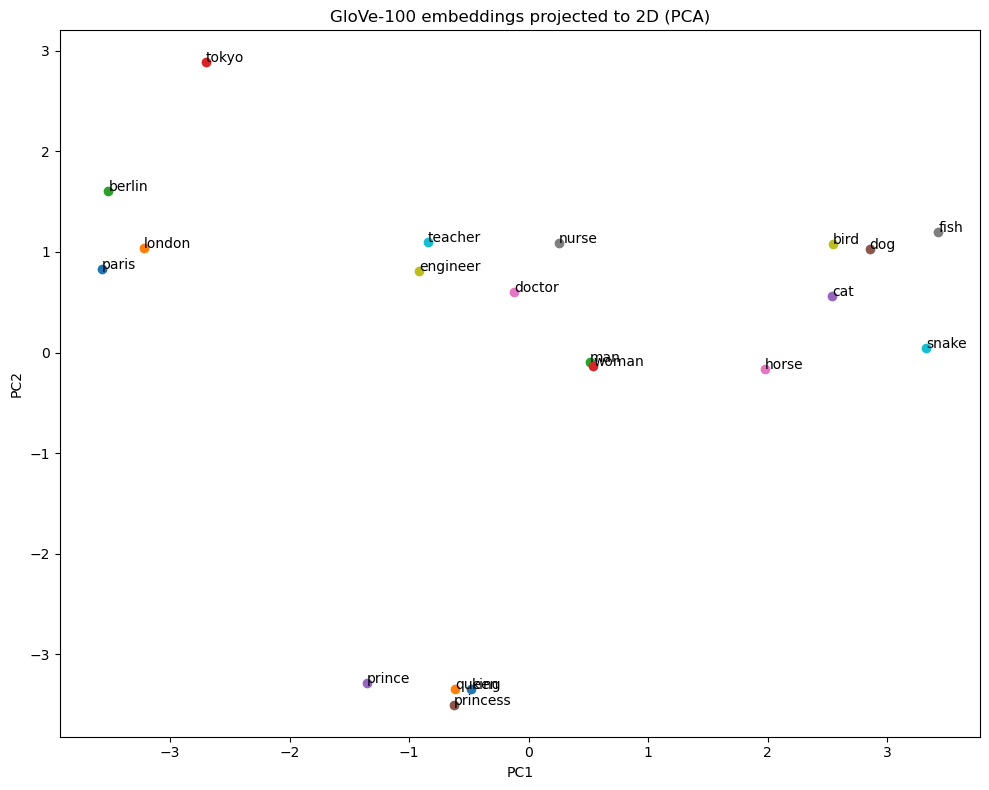

In [11]:
words_to_plot = [
    "king", "queen", "man", "woman", "prince", "princess",
    "doctor", "nurse", "engineer", "teacher",
    "paris", "london", "berlin", "tokyo",
    "cat", "dog", "horse", "fish", "bird", "snake",
]

valid_words = [word for word in words_to_plot if word in glove]
word_vectors = np.array([glove[word] for word in valid_words])
reduced = PCA(n_components=2).fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
for index, word in enumerate(valid_words):
    plt.scatter(reduced[index, 0], reduced[index, 1])
    plt.annotate(word, (reduced[index, 0], reduced[index, 1]), fontsize=10)

plt.title("GloVe-100 embeddings projected to 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Part B — Building a Bigram Language Model

> Part A represented meaning geometrically. Part B asks a completely different question: **given one word, how probable is the next word?**

We are now constructing a tiny statistical language model from scratch. There will be one model for Business text and one for Sports text.

## B1 — Corpus, tokenization, and counts

The labels are fixed throughout this section:

- `0 = Business`
- `1 = Sports`

A **unigram** is one token, such as `"market"`. A **bigram** is an adjacent pair, such as `("the", "market")`.

### Corpus and labels

**RUN**

- “Our training corpus is intentionally tiny so we can inspect it. Each tuple contains the text and its integer label.”
- “`class_docs[0]` will collect Business strings; `class_docs[1]` will collect Sports strings.”
- “The two test documents are held out from these training counts. Later, each class language model will score them.”
- “This is not enough data for a serious application—the small size is what makes smoothing and sanity checks especially visible.”

### Expected output

Four Business training documents and four Sports training documents.

In [12]:
corpus = [
    ("the market rose sharply after the rate decision", 0),
    ("stocks fell as investors worried about inflation", 0),
    ("the federal reserve cut interest rates yesterday", 0),
    ("oil prices climbed to a new high this week", 0),
    ("the team won the championship after a penalty shootout", 1),
    ("the goalkeeper saved three shots in extra time", 1),
    ("the striker scored twice in the second half", 1),
    ("the match ended in a draw after ninety minutes", 1),
]

test_docs = [
    ("inflation rose as oil prices hit record levels", 0),
    ("the goalkeeper made a stunning save in the final", 1),
]

class_docs = defaultdict(list)
for text, label in corpus:
    class_docs[label].append(text)

print("Business documents:", len(class_docs[0]))
print("Sports documents:", len(class_docs[1]))

Business documents: 4
Sports documents: 4


### Tokenize and build the global vocabulary

**RUN**

- “Tokenization is deliberately simple: lowercase and split on spaces. Production tokenizers handle punctuation and many edge cases, but that is not today's focus.”
- “`class_tokens[label]` is a list of tokenized documents for one class. It preserves document boundaries.”
- “`all_tokens` combines both classes so we can form one **global vocabulary**.”
- “`V` is the number of distinct tokens across the whole training corpus. Keep an eye on it because it will appear in every smoothed denominator.”

### Common mistake

Using a separate vocabulary size for each class. This lab uses the same global `V` for fair, consistent probability spaces.

In [13]:
def tokenise(text):
    return text.lower().split()


all_tokens = []
class_tokens = defaultdict(list)

for text, label in corpus:
    tokens = tokenise(text)
    all_tokens.extend(tokens)
    class_tokens[label].append(tokens)

global_vocab = set(all_tokens)
V = len(global_vocab)

print(f"Global vocabulary size V = {V}")
print("First Business token list:", class_tokens[0][0])
print("First Sports token list:", class_tokens[1][0])

Global vocabulary size V = 51
First Business token list: ['the', 'market', 'rose', 'sharply', 'after', 'the', 'rate', 'decision']
First Sports token list: ['the', 'team', 'won', 'the', 'championship', 'after', 'a', 'penalty', 'shootout']


### How does `zip(tokens, tokens[1:])` create bigrams?

For `tokens = ["the", "market", "rose"]`:

```text
tokens       = ["the",    "market", "rose"]
tokens[1:]   = [           "market", "rose"]
zip(...)     = ("the", "market"), ("market", "rose")
```

The two lists are offset by one position, so pairing them creates adjacent word pairs.

### Count unigrams and bigrams

**RUN**

- “For each class, `unigrams[token]` counts how often that token appeared.”
- “The nested bigram structure means `bigrams[w1][w2]` counts how often `w2` immediately followed `w1`.”
- “This is the code-level form of the mathematical counts we will use next.”
- “We print a few explicit values so the data structures do not remain mysterious.”

### Formula-to-code map

| Meaning | Python |
|---|---|
| $C(w_1)$ | `class_unigram_counts[label][w1]` |
| $C(w_1,w_2)$ | `class_bigram_counts[label][w1][w2]` |
| all tokenized docs for a class | `class_tokens[label]` |

In [14]:
class_unigram_counts = {}
class_bigram_counts = {}

for label, documents in class_tokens.items():
    unigrams = Counter()
    bigrams = defaultdict(Counter)
    for tokens in documents:
        for token in tokens:
            unigrams[token] += 1
        for w1, w2 in zip(tokens, tokens[1:]):
            bigrams[w1][w2] += 1
    class_unigram_counts[label] = unigrams
    class_bigram_counts[label] = bigrams

print("Business C('the'):", class_unigram_counts[0]["the"])
print("Business C('the', 'market'):", class_bigram_counts[0]["the"]["market"])
print("Sports C('the', 'goalkeeper'):", class_bigram_counts[1]["the"]["goalkeeper"])

for label, name in [(0, "Business"), (1, "Sports")]:
    all_bigrams = [
        (f"{w1} {w2}", count)
        for w1, followers in class_bigram_counts[label].items()
        for w2, count in followers.items()
    ]
    print(f"\n{name} sample bigrams:")
    for bigram, count in sorted(all_bigrams, key=lambda item: -item[1])[:5]:
        print(f"  {bigram!r}: {count}")

Business C('the'): 3
Business C('the', 'market'): 1
Sports C('the', 'goalkeeper'): 1

Business sample bigrams:
  'the market': 1
  'the rate': 1
  'the federal': 1
  'market rose': 1
  'rose sharply': 1

Sports sample bigrams:
  'the team': 1
  'the championship': 1
  'the goalkeeper': 1
  'the striker': 1
  'the second': 1


## B2 — Bigram probability and Laplace smoothing

Without smoothing, the probability of `w2` after `w1` is:

$$P(w_2\mid w_1)=\frac{C(w_1,w_2)}{C(w_1)}$$

### Ask the class

What happens if a perfectly reasonable bigram never appeared in our tiny training corpus?

Its count, and therefore its probability, is zero. When sentence probabilities are multiplied, **one zero makes the entire sentence probability zero**.

Laplace (add-1) smoothing gives every possible next word one imaginary count:

$$P(w_2\mid w_1)=\frac{C(w_1,w_2)+1}{C(w_1)+V}$$

| Formula | Python variable/expression |
|---|---|
| $C(w_1,w_2)$ | `bigram_counts[w1][w2]` |
| $C(w_1)$ | `unigram_counts[w1]` |
| $V$ | `vocab_size`, passed as global `V` |
| $\log P(w_2\mid w_1)$ | return value of `log_prob_smoothed(...)` |

Adding 1 to all $V$ possible next words adds a total of $V$ counts to the denominator.

### Implement smoothed probability

**RUN**

- “The numerator is the observed bigram count plus one.”
- “The denominator is the count of the first word plus the **global** vocabulary size.”
- “The function returns the natural log immediately, because later we will sum log-probabilities.”
- “The unseen Business bigram `the goalkeeper` is now small but finite, not negative infinity.”

### Common mistake

`V` is the **GLOBAL** vocabulary size used by this lab, not a class-specific vocabulary size.

### Key idea

Smoothing prevents zero probabilities. It does **not** understand whether a word sequence is linguistically plausible; it merely reallocates some probability mass.

In [15]:
def log_prob_smoothed(w1, w2, unigram_counts, bigram_counts, vocab_size):
    '''Return natural-log P(w2 | w1) with add-1 smoothing.'''
    numerator = bigram_counts[w1][w2] + 1
    denominator = unigram_counts[w1] + vocab_size
    return math.log(numerator / denominator)


seen_log_prob = log_prob_smoothed(
    "the", "market", class_unigram_counts[0], class_bigram_counts[0], V
)
unseen_log_prob = log_prob_smoothed(
    "the", "goalkeeper", class_unigram_counts[0], class_bigram_counts[0], V
)

print(f"Business log P(market | the): {seen_log_prob:.4f}")
print(f"Business log P(goalkeeper | the): {unseen_log_prob:.4f}")
print(f"Business P(goalkeeper | the): {math.exp(unseen_log_prob):.4f}")

Business log P(market | the): -3.2958
Business log P(goalkeeper | the): -3.9890
Business P(goalkeeper | the): 0.0185


### The `V = 5` numerical sanity check

Suppose the vocabulary is `{the, cat, sat, on, mat}`, so `V = 5`. We know:

- `C(the) = 4`
- `C(the, cat) = 3`
- `C(the, mat) = 1`
- the other three continuations have count 0.

The shared denominator is `C(the) + V = 4 + 5 = 9`:

- $P(\mathrm{cat}\mid\mathrm{the})=(3+1)/9=4/9$
- $P(\mathrm{mat}\mid\mathrm{the})=(1+1)/9=2/9$
- $P(\mathrm{sat}\mid\mathrm{the})=(0+1)/9=1/9$

`on` and `the` also receive `1/9`. The five probabilities must sum to 1.

### Verify the smoothing arithmetic

**RUN**

- “This is our unit test in plain sight. If these numbers are wrong, we should not trust the real model.”
- “Observed continuations keep larger probabilities, but unseen continuations are no longer impossible.”
- “Notice that `sat`, `on`, and `the` all get the same `1/9`. Add-1 smoothing knows only the counts; it does not know which continuation sounds sensible.”
- “Finally, summing over the vocabulary must give 1. A language model distributes one full unit of probability mass.”

### Expected output

`4/9`, `2/9`, three instances of `1/9`, and a total of `1.0000`.

In [16]:
toy_unigrams = Counter({"the": 4})
toy_bigrams = defaultdict(Counter)
toy_bigrams["the"] = Counter({"cat": 3, "mat": 1})
toy_vocab = ["cat", "mat", "sat", "on", "the"]
expected_probs = {"cat": 4 / 9, "mat": 2 / 9, "sat": 1 / 9, "on": 1 / 9, "the": 1 / 9}

toy_probs = {}
for w2 in toy_vocab:
    probability = math.exp(log_prob_smoothed("the", w2, toy_unigrams, toy_bigrams, 5))
    toy_probs[w2] = probability
    print(f"P({w2} | the) = {probability:.4f} (expected {expected_probs[w2]:.4f})")

print(f"Sum over vocabulary = {sum(toy_probs.values()):.4f}")
assert all(math.isclose(toy_probs[w], expected_probs[w]) for w in toy_vocab)
assert math.isclose(sum(toy_probs.values()), 1.0)

P(cat | the) = 0.4444 (expected 0.4444)
P(mat | the) = 0.2222 (expected 0.2222)
P(sat | the) = 0.1111 (expected 0.1111)
P(on | the) = 0.1111 (expected 0.1111)
P(the | the) = 0.1111 (expected 0.1111)
Sum over vocabulary = 1.0000


### Check the real vocabulary distribution

**RUN**

- “The same rule should normalize correctly when we replace the toy vocabulary with our actual global vocabulary.”
- “We calculate `P(w | the)` for every possible `w` in `global_vocab` and add them.”
- “A result extremely close to 1 confirms that our numerator and denominator are consistent.”

### Expected output

Approximately `1.0000`.

In [17]:
total_probability = sum(
    math.exp(
        log_prob_smoothed(
            "the", word, class_unigram_counts[0], class_bigram_counts[0], V
        )
    )
    for word in global_vocab
)
print(f"Sum of Business P(w | 'the') over global vocabulary: {total_probability:.4f}")
assert math.isclose(total_probability, 1.0)

Sum of Business P(w | 'the') over global vocabulary: 1.0000


## B3 — Log-likelihood classification

We now have two models:

- a Business language model built from class `0` counts;
- a Sports language model built from class `1` counts.

For a new document, we score every adjacent pair under each model and select the model that considers the entire sequence more likely.

Multiplying many tiny probabilities is numerically inconvenient and can underflow toward zero. Logs turn a product into a sum:

$$\log\left(\prod_i p_i\right)=\sum_i\log p_i$$

Natural-log probabilities between 0 and 1 are negative. Therefore:

> **`-15` is BETTER/HIGHER than `-25`.**

### Classify by log-likelihood

**RUN**

- “`log_likelihood` walks across adjacent pairs and adds each smoothed log-probability.”
- “The `scores` dictionary stores one total for Business and one for Sports.”
- “`max(scores, key=scores.get)` returns the dictionary key whose value is largest. Here that key is the predicted class label.”
- “Because the scores are negative, largest means closest to zero. Repeat with me: minus 15 beats minus 25.”
- “We then translate label 0 or 1 back into a readable class name.”

### What to notice

The correct class should generally have the higher log-likelihood, although this is a tiny model with considerable unseen vocabulary.

In [18]:
def log_likelihood(tokens, unigram_counts, bigram_counts, vocab_size):
    '''Sum log P(w2 | w1) over all consecutive pairs.'''
    total = 0.0
    for w1, w2 in zip(tokens, tokens[1:]):
        total += log_prob_smoothed(w1, w2, unigram_counts, bigram_counts, vocab_size)
    return total


label_names = {0: "Business", 1: "Sports"}

for text, true_label in test_docs:
    tokens = tokenise(text)
    scores = {
        label: log_likelihood(
            tokens,
            class_unigram_counts[label],
            class_bigram_counts[label],
            V,
        )
        for label in [0, 1]
    }
    predicted = max(scores, key=scores.get)
    print(f"\nDocument: {text!r}")
    print(f"  Business log-likelihood: {scores[0]:.4f}")
    print(f"  Sports log-likelihood:   {scores[1]:.4f}")
    print(f"  Predicted: {label_names[predicted]} | True: {label_names[true_label]}")


Document: 'inflation rose as oil prices hit record levels'
  Business log-likelihood: -26.9267
  Sports log-likelihood:   -27.5228
  Predicted: Business | True: Business

Document: 'the goalkeeper made a stunning save in the final'
  Business log-likelihood: -31.5883
  Sports log-likelihood:   -30.4058
  Predicted: Sports | True: Sports


## B4 — Perplexity

### Intuition first

> Perplexity measures how **surprised** the model is by the text.

**LOWER perplexity = BETTER fit.** A model assigning higher probability to the observed bigrams is less surprised.

For $M$ total bigrams:

$$\mathrm{PP}=\exp\left(-\frac{1}{M}\sum_{i=1}^{M}\log P(w_i\mid w_{i-1})\right)$$

| Formula | Python |
|---|---|
| sum of log-probabilities | `total_log_prob` |
| number of evaluated bigrams $M$ | `total_bigrams` |
| exponential | `math.exp(...)` |

We normalize by the total **number of bigrams**, not the number of documents, because every adjacent prediction contributes one term.

### Consistency requirement

Our probabilities use natural `math.log`, so perplexity reverses that log with `math.exp`. Do not combine `math.log2` with `math.exp`.

### Implement perplexity

**RUN**

- “This loop looks familiar because it accumulates exactly the same bigram log-probabilities as classification.”
- “The new piece is `total_bigrams`, which lets us compare datasets with different lengths.”
- “The minus sign turns the usual negative average log-probability into a positive quantity before exponentiating.”
- “If there are no bigrams—for example, only one token—we return infinity because there was no next-word prediction to evaluate.”

### Ask the class

Should lower or higher perplexity indicate the better language model?

### Answer

Lower. It means the model was less surprised by the observed word transitions.

In [19]:
def perplexity(tokenised_docs, unigram_counts, bigram_counts, vocab_size):
    '''Compute perplexity over all bigrams in tokenised_docs.'''
    total_log_prob = 0.0
    total_bigrams = 0
    for tokens in tokenised_docs:
        for w1, w2 in zip(tokens, tokens[1:]):
            total_log_prob += log_prob_smoothed(
                w1, w2, unigram_counts, bigram_counts, vocab_size
            )
            total_bigrams += 1
    if total_bigrams == 0:
        return float("inf")
    return math.exp(-total_log_prob / total_bigrams)


print("perplexity() is ready.")

perplexity() is ready.


### Hand-check: `the cat sat`

The sentence contains **two bigrams**, not three:

1. `the → cat`, with probability $4/9$;
2. `cat → sat`, with probability $3/7$.

Therefore:

$$\mathrm{PP}=\exp\left(-\frac{\log(4/9)+\log(3/7)}{2}\right)\approx 2.2913$$

This is another small arithmetic check before trusting results on the corpus.

### Verify perplexity by hand

**RUN**

- “Count predictions, not words. Three words create two adjacent next-word predictions.”
- “We take the average of the two natural log-probabilities, negate it, and use `exp`.”
- “The code mirrors the formula one piece at a time.”

### Expected output

Approximately `2.2913`.

In [20]:
p_cat_given_the = 4 / 9
p_sat_given_cat = 3 / 7
bigram_logs = [math.log(p_cat_given_the), math.log(p_sat_given_cat)]
manual_pp = math.exp(-sum(bigram_logs) / len(bigram_logs))

print(f"Hand-computed perplexity of 'the cat sat': {manual_pp:.4f}")
assert math.isclose(manual_pp, 2.29128784747792)

Hand-computed perplexity of 'the cat sat': 2.2913


### Compare Business and Sports models

**RUN**

- “Each row asks how surprised one language model is by documents from one class.”
- “The expected pattern is: Business LM has lower perplexity on Business; Sports LM has lower perplexity on Sports.”
- “Focus on the relative comparisons, not the absolute values. The training corpus has only eight documents.”
- “If cross-class values are close, that can reflect shared vocabulary such as `the`, `after`, and `in`.”

### TMA connection

TMA Q3 extends the same pattern to four classes: build per-class bigram counts, smooth with one global vocabulary, classify by the highest log-likelihood, and evaluate perplexity.

In [21]:
for eval_label in [0, 1]:
    print(f"\nEvaluation documents: {label_names[eval_label]}")
    for lm_label in [0, 1]:
        pp = perplexity(
            class_tokens[eval_label],
            class_unigram_counts[lm_label],
            class_bigram_counts[lm_label],
            V,
        )
        print(f"  {label_names[lm_label]} LM perplexity: {pp:.2f}")


Evaluation documents: Business
  Business LM perplexity: 26.11
  Sports LM perplexity: 51.78

Evaluation documents: Sports
  Business LM perplexity: 51.72
  Sports LM perplexity: 26.65


# Optional Extensions

These cells preserve the small extensions from the reference implementation for additional discussion or self-study.

### Bias and geometry extension

**OPTIONAL EXTENSION**

- “Nearest neighbours can expose social associations present in the source corpus.”
- “These outputs reflect patterns in training text, not objective truths about people or occupations.”
- “Analogy failures and uncomfortable associations are reasons to audit embeddings before downstream use.”

In [22]:
for word in ["programmer", "nurse", "ceo"]:
    print(f"{word} -> {nearest_neighbours(word, glove)}")

print("man : doctor :: woman :", solve_analogy("man", "doctor", "woman", glove))
print("nurse : doctor :: engineer :", solve_analogy("nurse", "doctor", "engineer", glove))

programmer -> ['programmers', 'animator', 'software', 'computer', 'technician', 'engineer', 'user', 'translator', 'linguist', 'entrepreneur']
nurse -> ['doctor', 'nurses', 'physician', 'nursing', 'dentist', 'therapist', 'midwife', 'hospital', 'surgeon', 'psychiatrist']
ceo -> ['executive', 'chairman', 'chief', 'cfo', 'vice', 'founder', 'managing', 'executives', 'manager', 'directors']
man : doctor :: woman : ['nurse', 'physician', 'doctors', 'pregnant', 'patient']
nurse : doctor :: engineer : ['scientist', 'master', 'inventor', 'architect', 'engineering']


### Sequence boundary extension

**OPTIONAL EXTENSION**

- “Our core tokenizer does not represent sentence beginnings or endings.”
- “Adding `<s>` and `</s>` lets a model count which words tend to start and finish documents.”
- “If we used these tokens in training, they would also need to be handled consistently in the global vocabulary and evaluation.”

In [23]:
def tokenise_with_boundaries(text):
    return ["<s>"] + text.lower().split() + ["</s>"]


print(tokenise_with_boundaries("the market rose"))

['<s>', 'the', 'market', 'rose', '</s>']


# Recap

| Concept | Core idea |
|---|---|
| PMI | Measures whether a word–context pair occurs more often than chance suggests. |
| GloVe | Maps each vocabulary word to a pretrained dense vector; meaning appears in vector relationships. |
| Cosine similarity | Compares vector direction after normalizing away magnitude. |
| Averaged embeddings | Averages all token vectors—including zero vectors for OOV tokens—into one document vector. |
| Bigram LM | Models the probability of a next word given the current word. |
| Laplace smoothing | Adds one to every possible continuation so unseen bigrams do not have zero probability. |
| Log-likelihood | Adds natural log-probabilities across a document; the higher (less negative) score wins. |
| Perplexity | Measures model surprise; lower is better, normalized by the number of bigrams. |

### TMA Q2b

Average GloVe token vectors → one 100-D document representation → classifier. Preserve the required OOV-as-zero behavior.

### TMA Q3

Build one bigram LM per class → use global-vocabulary Laplace smoothing → classify by log-likelihood → compare models with perplexity.

### Final takeaway

Story A models language through **semantic geometry**. Story B models language through **next-word probability**. They are different tools, and the right representation depends on the question we want the model to answer.